#### 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.manifold import LocallyLinearEmbedding
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

import sys
sys.path.append("../src")
from column_aliases import COLUMN_ALIASES

plt.style.use("seaborn-v0_8-whitegrid")
INPUT_FILE  = "../data/processed/selected_features.csv"
OUTPUT_FILE = "../data/processed/clustered.csv"
K_RANGE     = range(2, 9)
RANDOM_STATE = 42
print("Setup abgeschlossen.")

Setup abgeschlossen.


#### 2. Daten laden

In [2]:
df = pd.read_csv(INPUT_FILE)
print(f"Shape: {df.shape}, NaN gesamt: {df.isna().sum().sum()}")

Shape: (1142, 13), NaN gesamt: 0


#### 3. Standardisierung

In [3]:
scaler = StandardScaler()
X = scaler.fit_transform(df)
print(f"Feature-Matrix: {X.shape}")

Feature-Matrix: (1142, 13)


#### 4. k-Bestimmung – Elbow-Methode (k-Means)

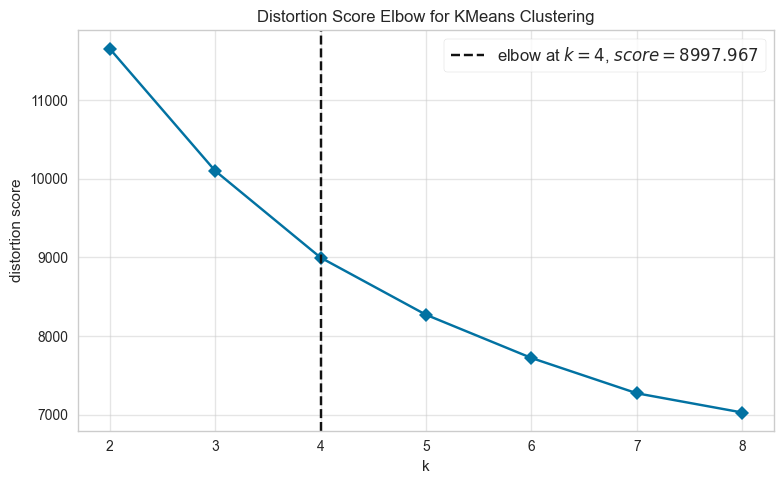

Ellenbogenwert: k = 4


In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
model = KMeans(random_state=RANDOM_STATE, n_init=10)
visualizer = KElbowVisualizer(model, k=K_RANGE, timings=False, ax=ax, force_model=True)
visualizer.fit(X)
elbow_k = visualizer.elbow_value_
ax.set_title("Elbow-Methode (WSS)")
ax.set_xlabel("Anzahl Cluster k")
ax.set_ylabel("WSS")
plt.tight_layout()
plt.savefig("../documentation/figures/clustering/clustering_elbow.png", dpi=150)
visualizer.show()
print(f"Ellenbogenwert: k = {elbow_k}")

#### 5. k-Bestimmung – Silhouetten-Score (k-Means)

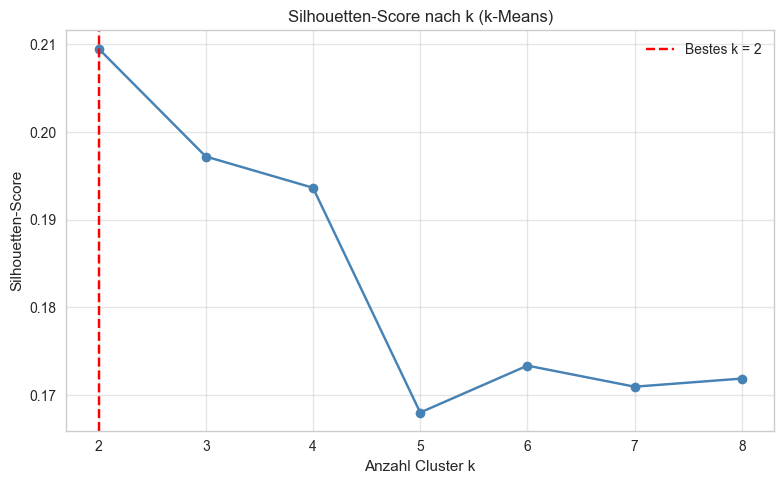

k=2: 0.2095
k=3: 0.1972
k=4: 0.1937
k=5: 0.1680
k=6: 0.1734
k=7: 0.1710
k=8: 0.1719


In [5]:
sil_scores = {}
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X)
    sil_scores[k] = silhouette_score(X, labels)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(sil_scores.keys()), list(sil_scores.values()), marker="o", color="steelblue")
best_k_sil = max(sil_scores, key=sil_scores.get)
ax.axvline(best_k_sil, color="red", linestyle="--", label=f"Bestes k = {best_k_sil}")
ax.set_xlabel("Anzahl Cluster k")
ax.set_ylabel("Silhouetten-Score")
ax.set_title("Silhouetten-Score nach k (k-Means)")
ax.legend()
plt.tight_layout()
plt.savefig("../documentation/figures/clustering/clustering_silhouette_k.png", dpi=150)
plt.show()

for k, s in sil_scores.items():
    print(f"k={k}: {s:.4f}")

#### 6. k-Bestimmung – BIC (GMM)

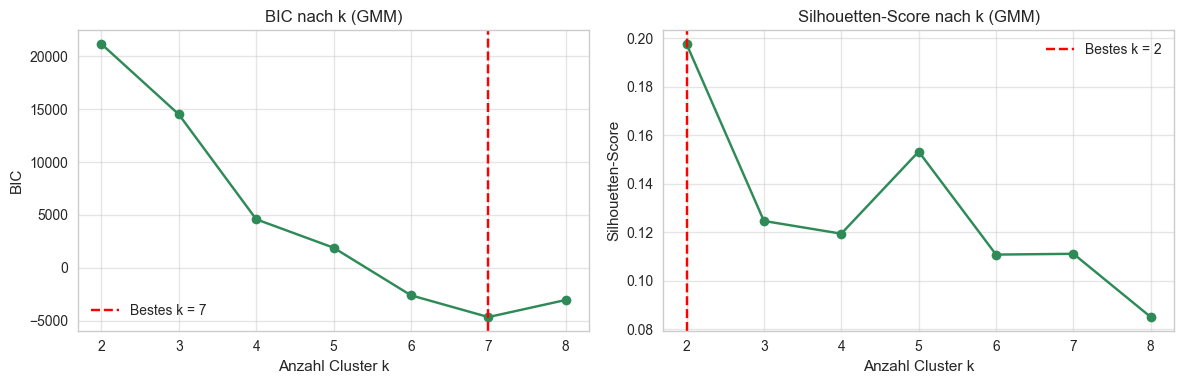

BIC-Minimum: k = 7 (-4663.2)
k=2: BIC=21168.4, Silhouette=0.1976
k=3: BIC=14508.1, Silhouette=0.1247
k=4: BIC=4588.1, Silhouette=0.1194
k=5: BIC=1897.7, Silhouette=0.1533
k=6: BIC=-2604.9, Silhouette=0.1108
k=7: BIC=-4663.2, Silhouette=0.1111
k=8: BIC=-3045.1, Silhouette=0.0851


In [6]:
bic_scores = {}
gmm_sil_scores = {}
for k in K_RANGE:
    gmm = GaussianMixture(n_components=k, random_state=RANDOM_STATE, n_init=5)
    gmm.fit(X)
    labels = gmm.predict(X)
    bic_scores[k] = gmm.bic(X)
    gmm_sil_scores[k] = silhouette_score(X, labels)

best_k_bic = min(bic_scores, key=bic_scores.get)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(bic_scores.keys()), list(bic_scores.values()), marker="o", color="seagreen")
axes[0].axvline(best_k_bic, color="red", linestyle="--", label=f"Bestes k = {best_k_bic}")
axes[0].set_xlabel("Anzahl Cluster k")
axes[0].set_ylabel("BIC")
axes[0].set_title("BIC nach k (GMM)")
axes[0].legend()

axes[1].plot(list(gmm_sil_scores.keys()), list(gmm_sil_scores.values()), marker="o", color="seagreen")
best_k_gmm_sil = max(gmm_sil_scores, key=gmm_sil_scores.get)
axes[1].axvline(best_k_gmm_sil, color="red", linestyle="--", label=f"Bestes k = {best_k_gmm_sil}")
axes[1].set_xlabel("Anzahl Cluster k")
axes[1].set_ylabel("Silhouetten-Score")
axes[1].set_title("Silhouetten-Score nach k (GMM)")
axes[1].legend()

plt.tight_layout()
plt.savefig("../documentation/figures/clustering/clustering_gmm_bic.png", dpi=150)
plt.show()

print(f"BIC-Minimum: k = {best_k_bic} ({bic_scores[best_k_bic]:.1f})")
for k, b in bic_scores.items():
    print(f"k={k}: BIC={b:.1f}, Silhouette={gmm_sil_scores[k]:.4f}")

#### 7. Finale k-Wahl und Begründung

In [7]:
# Ergebnisse der k-Bestimmung zusammenfassen
print("Zusammenfassung k-Bestimmung:")
print(f"  Elbow (k-Means WSS):        k = {elbow_k}")
print(f"  Silhouette (k-Means):       k = {best_k_sil} (Score: {sil_scores[best_k_sil]:.4f})")
print(f"  BIC-Minimum (GMM):          k = {best_k_bic}")
print(f"  Silhouette (GMM):           k = {best_k_gmm_sil} (Score: {gmm_sil_scores[best_k_gmm_sil]:.4f})")

# Finales k hier festlegen, ggf. manuell anpassen
K_FINAL = elbow_k if elbow_k is not None else best_k_sil
print(f"\nFinales k: {K_FINAL}")

Zusammenfassung k-Bestimmung:
  Elbow (k-Means WSS):        k = 4
  Silhouette (k-Means):       k = 2 (Score: 0.2095)
  BIC-Minimum (GMM):          k = 7
  Silhouette (GMM):           k = 2 (Score: 0.1976)

Finales k: 4


#### 8. k-Means – Finales Modell

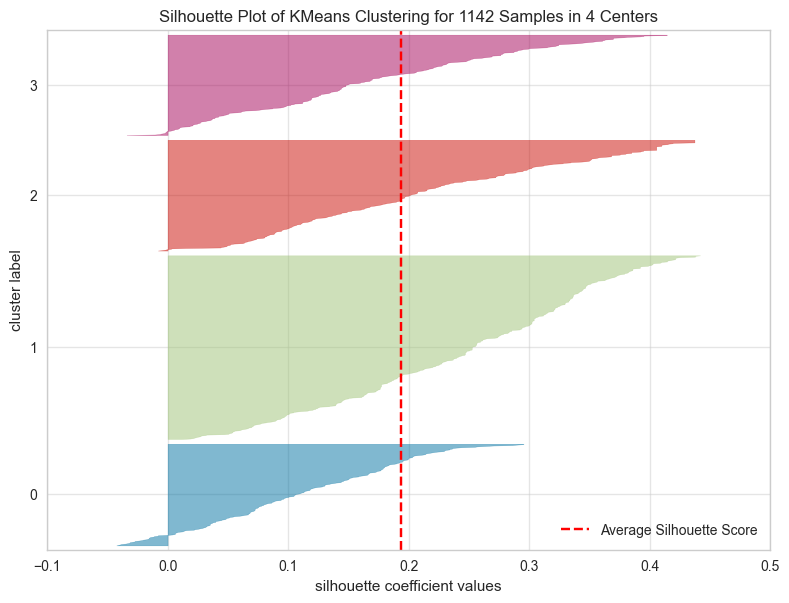

Silhouetten-Score: 0.1937
Cluster-Größen:
0    234
1    422
2    255
3    231


In [8]:
km_final = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=10)
km_labels = km_final.fit_predict(X)
km_sil = silhouette_score(X, km_labels)

fig, ax = plt.subplots(figsize=(8, 6))
vis = SilhouetteVisualizer(km_final, colors="yellowbrick", ax=ax, force_model=True)
vis.fit(X)
ax.set_title(f"k-Means Silhouettendiagramm (k={K_FINAL})")
plt.tight_layout()
plt.savefig("../documentation/figures/clustering/clustering_kmeans_silhouette.png", dpi=150)
vis.show()

cluster_sizes_km = pd.Series(km_labels).value_counts().sort_index()
print(f"Silhouetten-Score: {km_sil:.4f}")
print(f"Cluster-Größen:\n{cluster_sizes_km.to_string()}")

#### 9. GMM – Finales Modell

In [9]:
gmm_final = GaussianMixture(n_components=K_FINAL, random_state=RANDOM_STATE, n_init=5)
gmm_final.fit(X)
gmm_labels = gmm_final.predict(X)
gmm_sil = silhouette_score(X, gmm_labels)

cluster_sizes_gmm = pd.Series(gmm_labels).value_counts().sort_index()
print(f"BIC: {gmm_final.bic(X):.1f}")
print(f"Silhouetten-Score: {gmm_sil:.4f}")
print(f"Cluster-Größen:\n{cluster_sizes_gmm.to_string()}")

BIC: 4588.1
Silhouetten-Score: 0.1194
Cluster-Größen:
0    199
1    480
2     33
3    430


#### 10. Algorithmenvergleich

In [10]:
# Übereinstimmung der Cluster-Zuordnungen prüfen
agreement = np.mean(km_labels == gmm_labels)

print("Vergleich k-Means vs. GMM:")
print(f"  k-Means  Silhouette: {km_sil:.4f}")
print(f"  GMM      Silhouette: {gmm_sil:.4f}")
print(f"  GMM      BIC:        {gmm_final.bic(X):.1f}")
print(f"  Übereinstimmung der Labels: {agreement:.1%}")

# Kreuztabelle
cross = pd.crosstab(km_labels, gmm_labels,
                    rownames=["k-Means"], colnames=["GMM"])
print(f"\nKreuztabelle:\n{cross.to_string()}")

Vergleich k-Means vs. GMM:
  k-Means  Silhouette: 0.1937
  GMM      Silhouette: 0.1194
  GMM      BIC:        4588.1
  Übereinstimmung der Labels: 12.8%

Kreuztabelle:
GMM        0    1   2    3
k-Means                   
0        102  110  21    1
1         84    0   0  338
2          8  188   6   53
3          5  182   6   38


#### 11. Cluster-Visualisierung im LLE-Raum

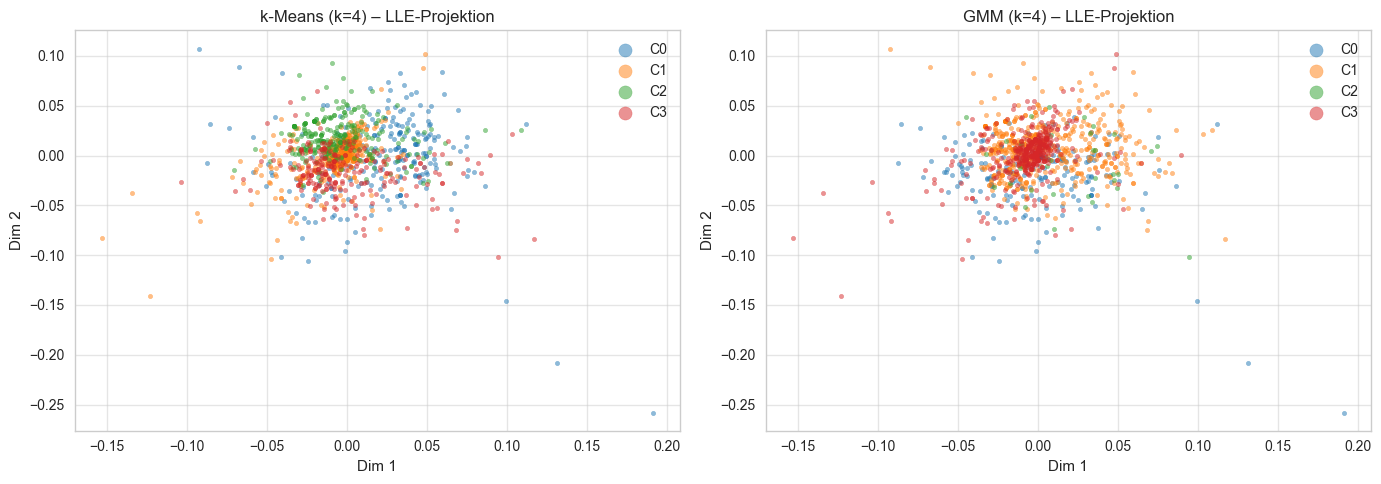

In [11]:
lle = LocallyLinearEmbedding(n_neighbors=15, n_components=2, random_state=RANDOM_STATE)
X_lle = lle.fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = plt.cm.tab10.colors

for cluster_id in range(K_FINAL):
    mask = km_labels == cluster_id
    axes[0].scatter(X_lle[mask, 0], X_lle[mask, 1],
                    alpha=0.5, s=10, color=colors[cluster_id], label=f"C{cluster_id}")
axes[0].set_title(f"k-Means (k={K_FINAL}) – LLE-Projektion")
axes[0].set_xlabel("Dim 1")
axes[0].set_ylabel("Dim 2")
axes[0].legend(markerscale=3)

for cluster_id in range(K_FINAL):
    mask = gmm_labels == cluster_id
    axes[1].scatter(X_lle[mask, 0], X_lle[mask, 1],
                    alpha=0.5, s=10, color=colors[cluster_id], label=f"C{cluster_id}")
axes[1].set_title(f"GMM (k={K_FINAL}) – LLE-Projektion")
axes[1].set_xlabel("Dim 1")
axes[1].set_ylabel("Dim 2")
axes[1].legend(markerscale=3)

plt.tight_layout()
plt.savefig("../documentation/figures/clustering/clustering_lle_vergleich.png", dpi=150)
plt.show()

#### 12. Deskriptive Statistiken je Cluster

In [12]:
# k-Means-Labels als Grundlage (ggf. auf GMM umstellen)
df_result = df.copy()
df_result["cluster_kmeans"] = km_labels
df_result["cluster_gmm"]    = gmm_labels

# Mittelwerte je k-Means-Cluster für alle Features
cluster_means = df_result.groupby("cluster_kmeans").mean().round(3)

# Lesbare Spaltennamen via COLUMN_ALIASES (soweit vorhanden)
alias_map = {v: k for k, v in COLUMN_ALIASES.items()}
cluster_means.columns = [alias_map.get(c, c) for c in cluster_means.columns]

print(f"Cluster-Mittelwerte (k-Means, k={K_FINAL}):")
print(cluster_means.T.to_string())

Cluster-Mittelwerte (k-Means, k=4):
cluster_kmeans                                                                                                                         0      1      2      3
Would you feel comfortable discussing a mental health disorder with your coworkers?                                                0.979  0.882  0.357  1.442
Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?                                     1.179  1.102  0.447  1.628
Do you think that team members/co-workers would view you more negatively if they knew you suffered from a mental health issue?     2.077  1.900  2.643  1.303
Do you currently have a mental health disorder?                                                                                    1.068  0.294  1.612  1.593
Do you feel that being identified as a person with a mental health issue would hurt your career?                                   2.470  2.280  3.031  1.771
Do you think tha

#### 13. Cluster-Größen im Überblick

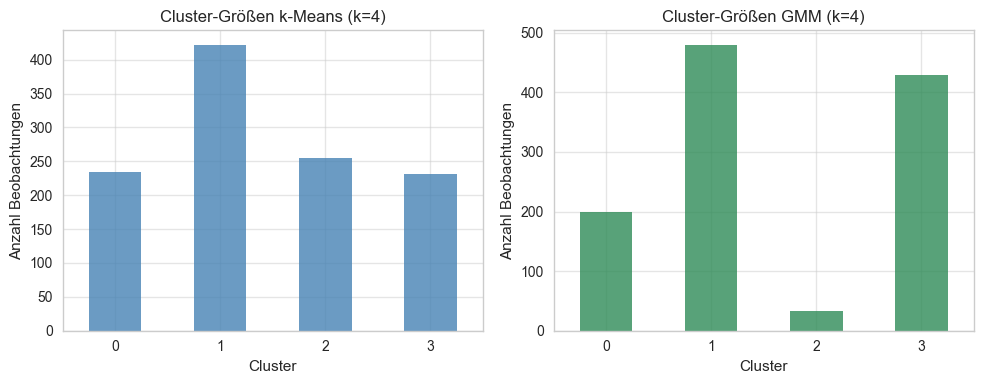

k-Means: {0: 234, 1: 422, 2: 255, 3: 231}
GMM:     {0: 199, 1: 480, 2: 33, 3: 430}


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

cluster_sizes_km.plot(kind="bar", ax=axes[0], color="steelblue", alpha=0.8)
axes[0].set_title(f"Cluster-Größen k-Means (k={K_FINAL})")
axes[0].set_xlabel("Cluster")
axes[0].set_ylabel("Anzahl Beobachtungen")
axes[0].tick_params(axis="x", rotation=0)

cluster_sizes_gmm.plot(kind="bar", ax=axes[1], color="seagreen", alpha=0.8)
axes[1].set_title(f"Cluster-Größen GMM (k={K_FINAL})")
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("Anzahl Beobachtungen")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig("../documentation/figures/clustering/clustering_groessen.png", dpi=150)
plt.show()

print("k-Means:", cluster_sizes_km.to_dict())
print("GMM:    ", cluster_sizes_gmm.to_dict())

#### 14. Exportieren

In [14]:
df_result.to_csv(OUTPUT_FILE, index=False)
print(f"Gespeichert: {OUTPUT_FILE}")
print(f"Shape: {df_result.shape}")

Gespeichert: ../data/processed/clustered.csv
Shape: (1142, 15)
